/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


>>> Lendo DADOS de: /home/tandrade/Flavour_Anomalies/Data/final_data_skim.root
    -> Conversão para DataFrame (Total de linhas: 6267972)
    -> Após cortes: 961428
>>> Lendo MC de: /home/tandrade/Flavour_Anomalies/Data/final_mc_jpsi_skim.root
    -> Conversão para DataFrame (Total de linhas: 250628)
    -> Após cortes: 152839
>>> Sucesso! df_data e df_mc estão prontos.
>>> Construindo modelo Zfit...
>>> Executando Fit...
Status do Fit: VÁLIDO ✅
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('mass',) shape=(961428, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.0

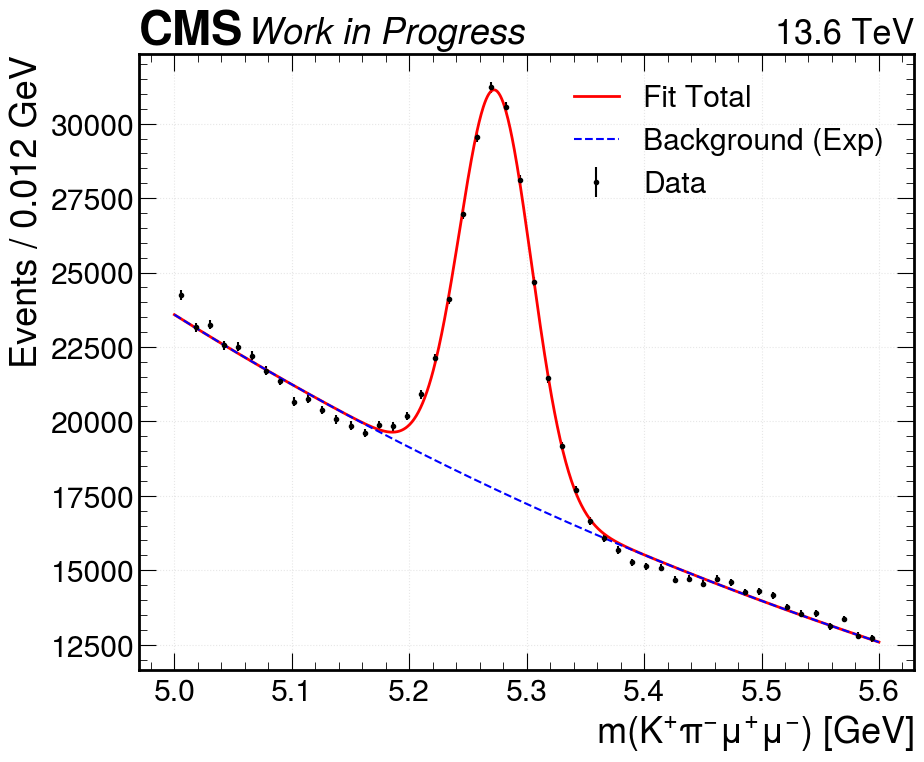

>>> Calculando sWeights...
>>> Gerando plots comparativos com Ratio...
   Plotting pt...


FileNotFoundError: [Errno 2] No such file or directory: 'Plots/sPlot_Comp_pt_zfit.png'

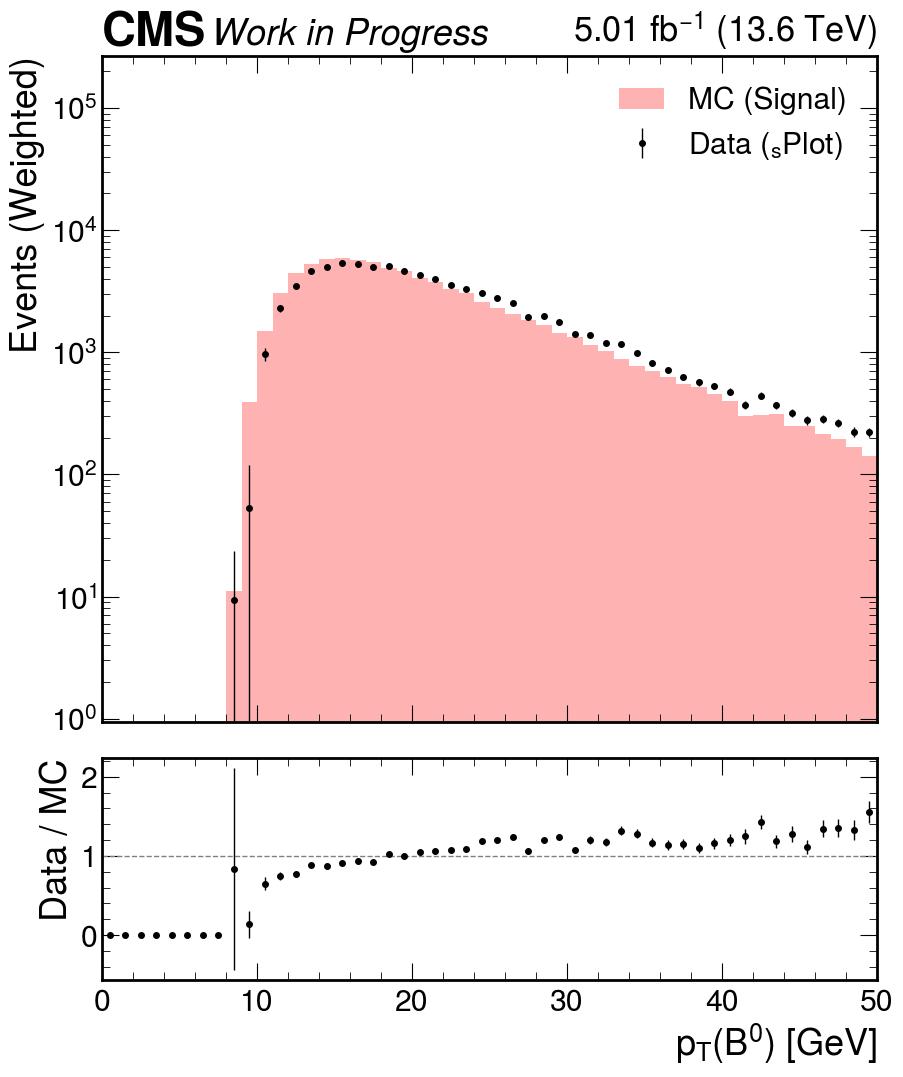

FileNotFoundError: [Errno 2] No such file or directory: 'Plots/sPlot_Comp_pt_zfit.png'

In [3]:
%run ./sPlot_Zfit.ipynb

In [47]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from hep_ml.reweight import GBReweighter

# Configuração de estilo CMS
plt.style.use(hep.style.CMS) 

In [48]:
features_raw = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
    "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
    "BToTrkTrkMuMu_trk1_dca_good", "BToTrkTrkMuMu_trk1_dcaErr_good",
    "BToTrkTrkMuMu_trk2_dca_good", "BToTrkTrkMuMu_trk2_dcaErr_good",
    'BToTrkTrkMuMu_l_xy_good', 'BToTrkTrkMuMu_l_xy_unc_good',
    'BToTrkTrkMuMu_dca_good', 'BToTrkTrkMuMu_dcaErr_good',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good', 'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good', 'BToTrkTrkMuMu_svprob_good'
]
cols_sel = ["BToTrkTrkMuMu_fit_mass_Kpi_good", "MuMu_mass_good", "HLT_DoubleMu4_3_LowMass"] 

In [49]:
def load_data_clean(path):
    with uproot.open(path) as f:
        df = ak.to_dataframe(f["tree_ML"].arrays(features_raw + cols_sel, library="ak"))
    mask = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6) & \
           (df['MuMu_mass_good'] > 2.9) & (df['MuMu_mass_good'] < 3.3) & (df['HLT_DoubleMu4_3_LowMass'] == 1)
    return df[mask].copy()

df_data_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_data_skim.root")
df_mc_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_mc_jpsi_skim.root") 

In [50]:
df_data_bdt["sweight_sig"] = df_data_bdt["sweight_sig"].values if "sweight_sig" in df_data_bdt.columns else 1.0 # Correção de segurança caso não exista

In [51]:
features_final = [  
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
     "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
     "trk1_dca_sig", "trk2_dca_sig"
]

In [52]:
for df_tmp in [df_data_bdt, df_mc_bdt]:
    df_tmp['trk1_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk1_dca_good'] / df_tmp['BToTrkTrkMuMu_trk1_dcaErr_good'].replace(0, np.nan)
    df_tmp['trk2_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk2_dca_good'] / df_tmp['BToTrkTrkMuMu_trk2_dcaErr_good'].replace(0, np.nan)
    df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_tmp.dropna(subset=features_final + (["sweight_sig"] if "sweight_sig" in df_tmp.columns else []), inplace=True)

print(f"Dados limpos. Data: {len(df_data_bdt)}, MC: {len(df_mc_bdt)}") 

Dados limpos. Data: 961428, MC: 152839


In [53]:
reweighter = GBReweighter(
    n_estimators=80, 
    learning_rate=0.1, 
    max_depth=3, 
    gb_args={'random_state': 42}
)

reweighter.fit(
    df_mc_bdt[features_final], 
    df_data_bdt[features_final], 
    target_weight=df_data_bdt["sweight_sig"]
) 

GBReweighter(gb_args={'random_state': 42}, learning_rate=0.1, n_estimators=80)

In [54]:
df_mc_bdt['w_rw'] = reweighter.predict_weights(df_mc_bdt[features_final]) 

In [55]:
df_data_bdt['label'] = 1
df_mc_bdt['label'] = 0 

In [56]:
df_data_bdt['weight_unweighted'] = df_data_bdt['sweight_sig']
df_mc_bdt['weight_unweighted'] = 1.0 # MC padrão sem peso 

In [57]:
df_data_bdt['weight_reweighted'] = df_data_bdt['sweight_sig']
df_mc_bdt['weight_reweighted'] = df_mc_bdt['w_rw']  

df_combined = pd.concat([df_data_bdt, df_mc_bdt], ignore_index=True) 

In [58]:
X = df_combined[features_final]
y = df_combined['label']
w_unweighted = df_combined['weight_unweighted']
w_reweighted = df_combined['weight_reweighted']

X_train, X_test, y_train, y_test, wu_train, wu_test, wr_train, wr_test = train_test_split(
    X, y, w_unweighted, w_reweighted, test_size=0.3, random_state=42
) 

In [59]:
bdt_unweighted = xgb.XGBClassifier(n_estimators=100, 
                                   max_depth=3, 
                                   learning_rate=0.1, 
                                   random_state=42)
bdt_unweighted.fit(X_train, y_train, sample_weight=np.abs(wu_train)) 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [60]:
# --- MODIFICAÇÃO PARA O GRÁFICO DE LOGLOSS ---
bdt_reweighted = xgb.XGBClassifier(n_estimators=100, 
                                   max_depth=3, 
                                   learning_rate=0.1, 
                                   random_state=42,
                                   eval_metric='logloss') # Adicionado eval_metric

eval_set = [(X_train, y_train), (X_test, y_test)]
eval_weights = [np.abs(wr_train), np.abs(wr_test)]

bdt_reweighted.fit(X_train, y_train, 
                   sample_weight=np.abs(wr_train),
                   eval_set=eval_set, 
                   sample_weight_eval_set=eval_weights, 
                   verbose=False)
# ----------------------------------------------

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [61]:
y_pred_unweighted = bdt_unweighted.predict_proba(X_test)[:, 1]
y_pred_reweighted = bdt_reweighted.predict_proba(X_test)[:, 1] 

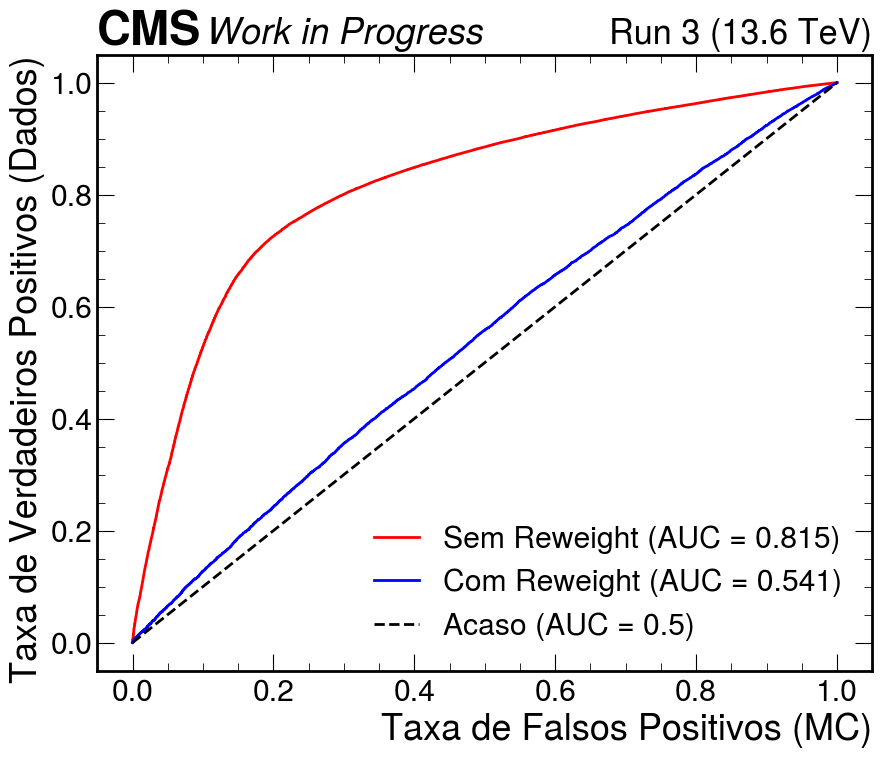

AUC Antes do reweight: 0.815 (Quanto maior, mais diferentes eles são)
AUC Depois do reweight: 0.541 (O ideal é estar próximo de 0.500)


In [62]:
fpr_u, tpr_u, _ = roc_curve(y_test, y_pred_unweighted, sample_weight=wu_test)
auc_u = auc(fpr_u, tpr_u)

fpr_r, tpr_r, _ = roc_curve(y_test, y_pred_reweighted, sample_weight=wr_test)
auc_r = auc(fpr_r, tpr_r)

# --- PLOT DAS CURVAS ROC ---
plt.figure(figsize=(10, 8))
hep.cms.label(data=True, label = "Work in Progress", lumi=None, year="Run 3", com = 13.6) 

plt.plot(fpr_u, tpr_u, label=f'Sem Reweight (AUC = {auc_u:.3f})', lw=2, color='red')
plt.plot(fpr_r, tpr_r, label=f'Com Reweight (AUC = {auc_r:.3f})', lw=2, color='blue')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos (MC)')
plt.ylabel('Taxa de Verdadeiros Positivos (Dados)')
plt.title(' ')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Antes do reweight: {auc_u:.3f} (Quanto maior, mais diferentes eles são)")
print(f"AUC Depois do reweight: {auc_r:.3f} (O ideal é estar próximo de 0.500)") 

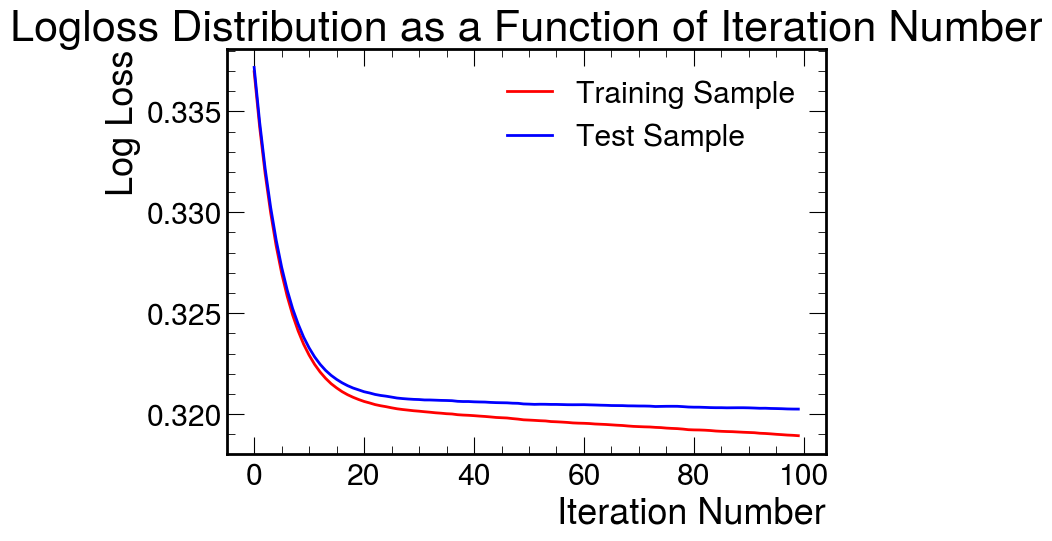

In [63]:
# --- PLOT DA CURVA DE APRENDIZADO (LOG LOSS) ---
results = bdt_reweighted.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(8, 6))
# validation_0 é o treino, validation_1 é o teste
plt.plot(x_axis, results['validation_0']['logloss'], label='Training Sample', color='red', lw=2)
plt.plot(x_axis, results['validation_1']['logloss'], label='Test Sample', color='blue', lw=2)

plt.xlabel('Iteration Number')
plt.ylabel('Log Loss')
plt.title('Logloss Distribution as a Function of Iteration Number')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_21618/4291676972.py:1: UserWarning: feature_importances_ of gb returns importances corresponding to used columns 
  importances_raw = reweighter.gb.feature_importances_


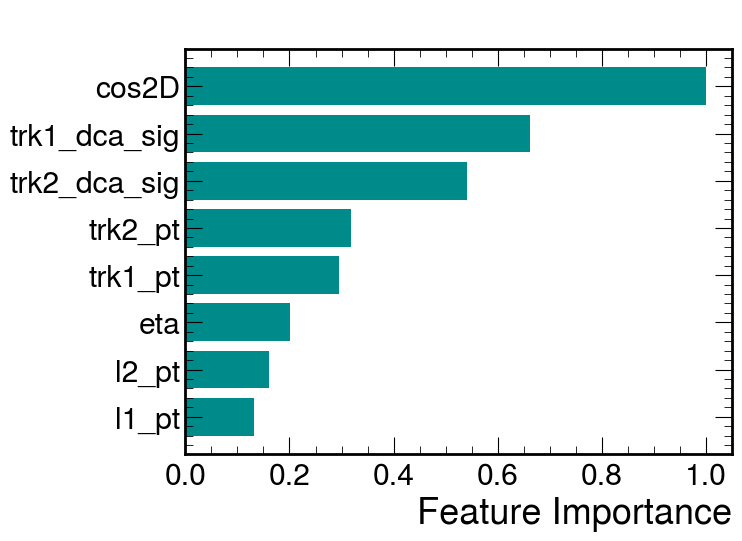

In [64]:
importances_raw = reweighter.gb.feature_importances_
importances_norm = importances_raw / np.max(importances_raw)
indices = np.argsort(importances_norm)

clean_features = [
    f.replace('BToTrkTrkMuMu_fit_', '').replace('BToTrkTrkMuMu_', '').replace('_good', '') 
    for f in features_final
]

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances_norm[indices], color='darkcyan')
plt.yticks(range(len(indices)), [clean_features[i] for i in indices])
plt.title(' ')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show() 

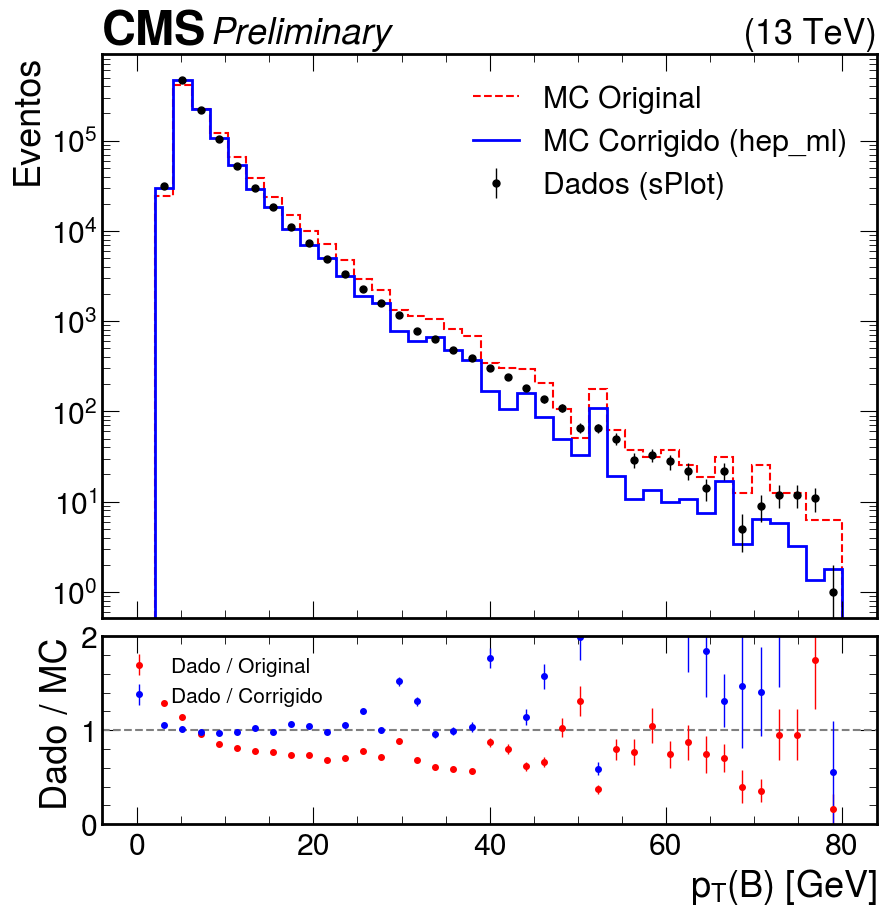

In [66]:
def plot_final_comparison(var, bins, label_x):
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(10, 10), 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, 
                                   sharex=True)
    hep.cms.label("Preliminary", data=True, ax=ax)

    h_data, _ = np.histogram(df_data_bdt[var], bins=bins, weights=df_data_bdt['sweight_sig'])
    h_data_err = np.sqrt(np.histogram(df_data_bdt[var], bins=bins, weights=df_data_bdt['sweight_sig']**2)[0])
    h_mc_raw, _ = np.histogram(df_mc_bdt[var], bins=bins)
    h_mc_corr, _ = np.histogram(df_mc_bdt[var], bins=bins, weights=df_mc_bdt['w_rw'])

    norm = h_data.sum()
    h_mc_raw = h_mc_raw.astype(float) * (norm / h_mc_raw.sum())
    h_mc_corr = h_mc_corr.astype(float) * (norm / h_mc_corr.sum())

    hep.histplot(h_data, bins=bins, yerr=h_data_err, label='Dados (sPlot)', ax=ax, histtype='errorbar', color='black')
    hep.histplot(h_mc_raw, bins=bins, label='MC Original', ax=ax, color='red', linestyle='--')
    hep.histplot(h_mc_corr, bins=bins, label='MC Corrigido (hep_ml)', ax=ax, color='blue', lw=2)
    
    ax.set_yscale('log')
    ax.set_ylabel("Eventos")
    ax.legend()

    with np.errstate(divide='ignore', invalid='ignore'):
        r_raw = np.divide(h_data, h_mc_raw)
        r_corr = np.divide(h_data, h_mc_corr)
        
        err_r_raw = r_raw * np.divide(h_data_err, h_data)
        err_r_corr = r_corr * np.divide(h_data_err, h_data)
    
    rax.axhline(1, color='gray', linestyle='--')
    
    hep.histplot(r_raw, bins=bins, yerr=err_r_raw, ax=rax, color='red', 
                 histtype='errorbar', marker='o', markersize=4, label='Dado / Original')
    hep.histplot(r_corr, bins=bins, yerr=err_r_corr, ax=rax, color='blue', 
                 histtype='errorbar', marker='o', markersize=4, label='Dado / Corrigido')
    
    rax.set_ylim(0., 2.0)
    rax.set_ylabel("Dado / MC")
    rax.set_xlabel(label_x)
    rax.legend(loc='upper left', fontsize='xx-small', ncol=1, frameon=False)    
    plt.show()

plot_final_comparison("BToTrkTrkMuMu_fit_l1_pt_good", np.linspace(0, 80, 40), r"$p_{T}(B)$ [GeV]")